# Unemployment Analysis with Python

## Objective

The objective of this project is to perform exploratory data analysis
on unemployment data in India and identify regional and temporal trends,
with particular focus on changes during the COVID-19 pandemic.

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset

The analysis uses the "Unemployment in India" dataset containing
monthly unemployment information for Indian states and regions.

The dataset includes unemployment rate, estimated employment,
labour participation rate, and rural/urban area information.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [2]:
df = pd.read_csv("dataset/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 1. Dataset Overview

Before performing analysis, we inspect the structure, size, data types, and basic information of the dataset.

In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types and non-null counts
print("\nDataset Information:")
df.info()

Dataset Shape: (768, 7)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ K

## 2. Missing Value Analysis

We check for missing values in each column before performing further analysis.

In [4]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


## 3. Handling Missing Values

We check whether the missing values belong to completely empty rows before deciding how to handle them.

In [5]:
# Check rows where all values are missing
empty_rows = df.isnull().all(axis=1).sum()

print("Completely Empty Rows:", empty_rows)

Completely Empty Rows: 28


In [6]:
df = df.dropna(how="all").reset_index(drop=True)

print("Dataset Shape After Removing Empty Rows:", df.shape)

Dataset Shape After Removing Empty Rows: (740, 7)


In [7]:
# Remove completely empty rows
df = df.dropna(how="all").reset_index(drop=True)

print("Dataset Shape After Removing Empty Rows:", df.shape)

Dataset Shape After Removing Empty Rows: (740, 7)


In [8]:
# Check data types after removing empty rows
print("Data Types:")
print(df.dtypes)

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


In [9]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [10]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [11]:
df.columns = df.columns.str.strip()

In [12]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print("Date data type after conversion:")
print(df["Date"].dtype)

print("\nFirst 5 dates:")
print(df["Date"].head())

Date data type after conversion:
datetime64[ns]

First 5 dates:
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [13]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [14]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check the data type after conversion
print("Date data type after conversion:")
print(df["Date"].dtype)

# Display the first 5 dates
print("\nFirst 5 dates:")
print(df["Date"].head())

Date data type after conversion:
datetime64[ns]

First 5 dates:
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [15]:
# Check unique values in categorical columns

print("Regions:")
print(df["Region"].unique())

print("\nFrequency:")
print(df["Frequency"].unique())

print("\nArea:")
print(df["Area"].unique())


Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Frequency:
[' Monthly' 'Monthly']

Area:
['Rural' 'Urban']


In [16]:
# Remove extra spaces from text columns

df["Region"] = df["Region"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()
df["Area"] = df["Area"].str.strip()

# Check again
print("Frequency after cleaning:")
print(df["Frequency"].unique())

print("\nArea after cleaning:")
print(df["Area"].unique())

Frequency after cleaning:
['Monthly']

Area after cleaning:
['Rural' 'Urban']


In [17]:
# Summary statistics for numerical columns

print("Summary Statistics:")
print(df.describe())

Summary Statistics:
                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                     

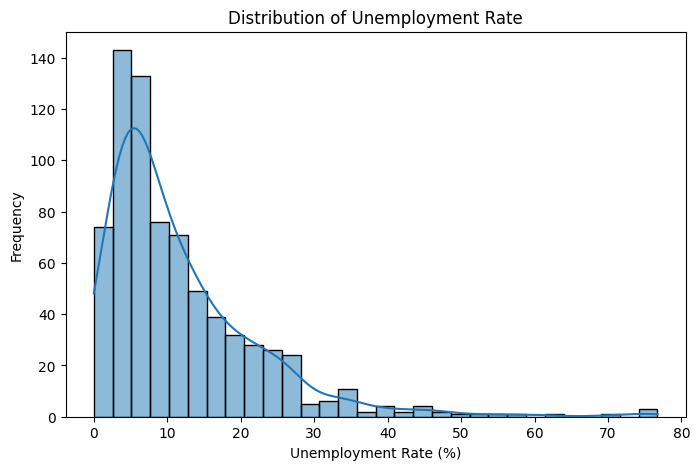

In [18]:
# Distribution of Unemployment Rate

plt.figure(figsize=(8, 5))

sns.histplot(df["Estimated Unemployment Rate (%)"], bins=30, kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

In [19]:
# Average unemployment rate by region
region_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate by Region:")
print(region_unemployment)

Average Unemployment Rate by Region:
Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64


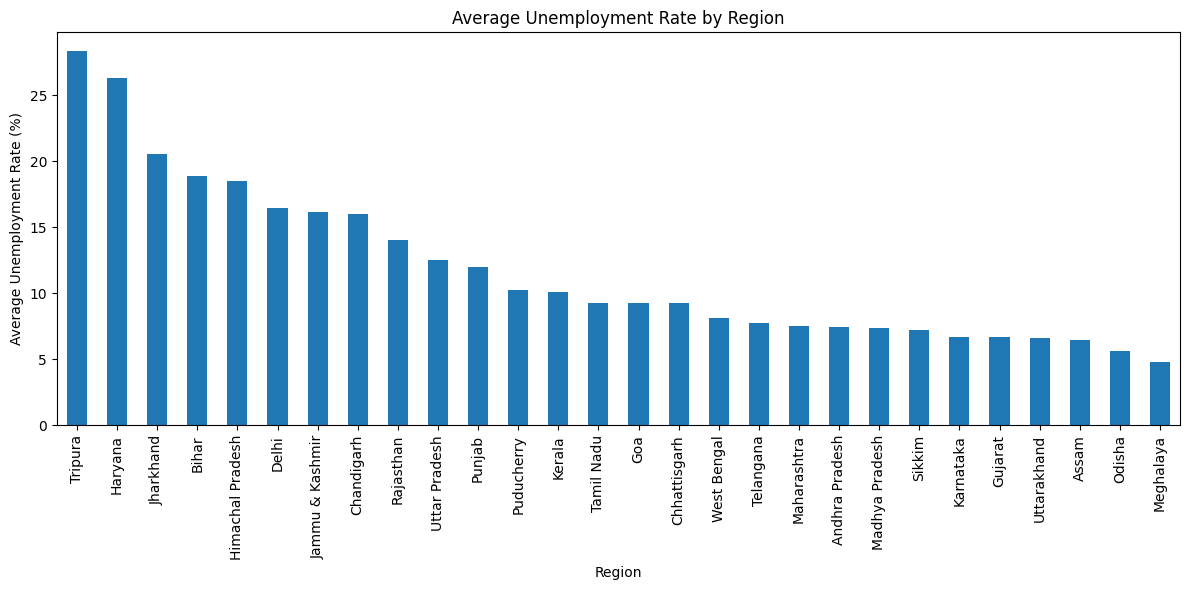

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

region_unemployment.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [21]:
area_unemployment = df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate by Area:")
print(area_unemployment)

Average Unemployment Rate by Area:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


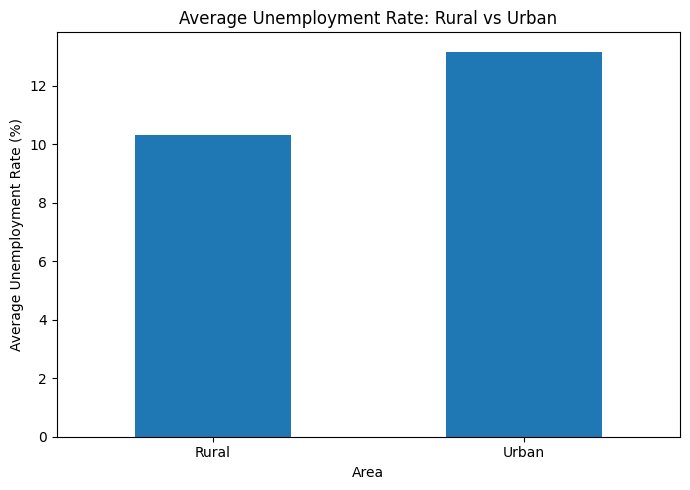

In [22]:
plt.figure(figsize=(7, 5))

area_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# Average unemployment rate by date

date_unemployment = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate by Date:")
print(date_unemployment)

Average Unemployment Rate by Date:
Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


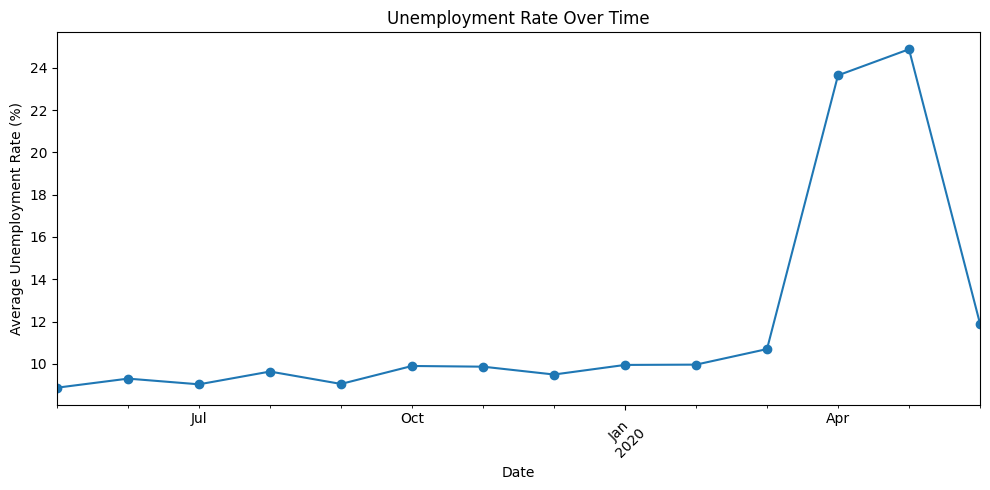

In [24]:
plt.figure(figsize=(10, 5))

date_unemployment.plot(kind="line", marker="o")

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

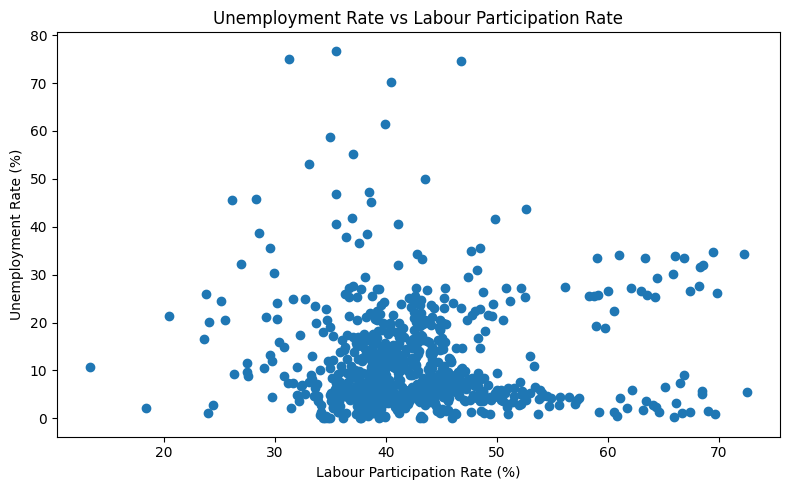

In [25]:
# Relationship between unemployment rate and labour participation rate

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Estimated Labour Participation Rate (%)"],
    df["Estimated Unemployment Rate (%)"]
)

plt.title("Unemployment Rate vs Labour Participation Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")

plt.tight_layout()
plt.show()

In [26]:
correlation = df["Estimated Labour Participation Rate (%)"].corr(
    df["Estimated Unemployment Rate (%)"]
)

print("Correlation between Labour Participation Rate and Unemployment Rate:")
print(correlation)

Correlation between Labour Participation Rate and Unemployment Rate:
0.0025579648339084824


In [27]:
# Correlation matrix
correlation_matrix = df.select_dtypes(include="number").corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


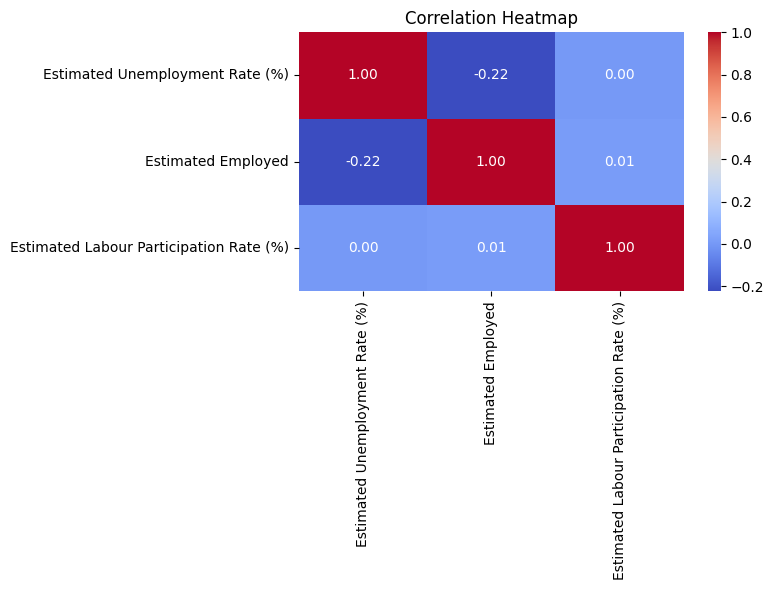

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [29]:
# Key Insights

print("Key Insights:")
print("1. The average unemployment rate is higher in urban areas than rural areas.")
print("2. Unemployment increased sharply during April and May 2020.")
print("3. Haryana and Tripura have relatively high average unemployment rates in this dataset.")
print("4. The correlation between unemployment rate and labour participation rate is very weak.")
print("5. There is a weak negative correlation between unemployment rate and estimated employment.")

Key Insights:
1. The average unemployment rate is higher in urban areas than rural areas.
2. Unemployment increased sharply during April and May 2020.
3. Haryana and Tripura have relatively high average unemployment rates in this dataset.
4. The correlation between unemployment rate and labour participation rate is very weak.
5. There is a weak negative correlation between unemployment rate and estimated employment.


# Conclusion

This analysis explored unemployment trends in India using data on unemployment rate, estimated employment, labour participation rate, area, region, and date.

The analysis shows differences in unemployment rates between rural and urban areas and significant changes over time. The unemployment rate increased sharply during April and May 2020 in the dataset.

The correlation analysis shows a very weak relationship between unemployment rate and labour participation rate, while unemployment rate has a weak negative correlation with estimated employment.

Overall, the analysis demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to clean, explore, visualize, and interpret unemployment data.